<a href="https://colab.research.google.com/github/ZehanQin/Card-D.-Krueger-A.-B.-1994-.-Minimum-Wages-and-Employment-Replication/blob/main/notebooks/03_Extension_and_Results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Import

In [46]:
raw_url = "https://raw.githubusercontent.com/ZehanQin/Card-D.-Krueger-A.-B.-1994-.-Minimum-Wages-and-Employment-Replication/refs/heads/main/data/raw/public.dat"

In [47]:
import pandas as pd

col_specs = [(0, 3),(4, 5),(6, 7),(8, 9),(10,11),(12,13),(14,15),(16,17),(18,19),(20,21),
             (25,30),(31,36),(37,42),(43,48),(83,88),(89,94),(95,100),(109,110),(121,126),(127,132),(133,138),(139,144),(173,178),(179,184),(185,190)]
col_names = ['SHEET', 'CHAIN', 'CO_OWNED', 'STATE','SOUTNJ','CENTRALJ','NORTHJ','PA1','PA2','SHORE',
             'EMPFT','EMPPT','NMGRS','WAGE_ST','PSODA','PFRY','PENTREE','STATUS2','EMPFT2','EMPPT2','NMGRS2','WAGE_ST2','PSODA2','PFRY2','PENTREE2']

df_raw = pd.read_fwf(raw_url, colspecs=col_specs, names=col_names)
df_raw.head()

,SHEET,CHAIN,CO_OWNED,STATE,SOUTNJ,CENTRALJ,NORTHJ,PA1,PA2,SHORE,...,PFRY,PENTREE,STATUS2,EMPFT2,EMPPT2,NMGRS2,WAGE_ST2,PSODA2,PFRY2,PENTREE2
0,46,1,0,0,0,0,0,1,0,0,...,1.03,0.52,1,3.50,35.00,3.00,4.30,1.03,.,0.94
1,49,2,0,0,0,0,0,1,0,0,...,0.90,2.35,1,0.00,15.00,4.00,4.45,1.01,0.89,2.35
2,506,2,1,0,0,0,0,1,0,0,...,0.74,2.33,1,3.00,7.00,4.00,5.00,0.95,0.74,2.33
3,56,4,1,0,0,0,0,1,0,0,...,0.82,1.79,1,0.00,36.00,2.00,5.25,0.92,0.79,0.87
4,61,4,1,0,0,0,0,1,0,0,...,0.77,1.65,1,28.00,3.00,6.00,4.75,1.01,0.84,0.95


In [48]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 25 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   SHEET     410 non-null    int64 
 1   CHAIN     410 non-null    int64 
 2   CO_OWNED  410 non-null    int64 
 3   STATE     410 non-null    int64 
 4   SOUTNJ    410 non-null    int64 
 5   CENTRALJ  410 non-null    int64 
 6   NORTHJ    410 non-null    int64 
 7   PA1       410 non-null    int64 
 8   PA2       410 non-null    int64 
 9   SHORE     410 non-null    int64 
 10  EMPFT     410 non-null    object
 11  EMPPT     410 non-null    object
 12  NMGRS     410 non-null    object
 13  WAGE_ST   410 non-null    object
 14  PSODA     410 non-null    object
 15  PFRY      410 non-null    object
 16  PENTREE   410 non-null    object
 17  STATUS2   410 non-null    int64 
 18  EMPFT2    410 non-null    object
 19  EMPPT2    410 non-null    object
 20  NMGRS2    410 non-null    object
 21  WAGE_ST2  410 no

Code Explanation: Data type and structure validation

# Phase 2

In [49]:
import numpy as np
import pandas as pd

In [50]:
df_raw.isna()

,SHEET,CHAIN,CO_OWNED,STATE,SOUTNJ,CENTRALJ,NORTHJ,PA1,PA2,SHORE,...,PFRY,PENTREE,STATUS2,EMPFT2,EMPPT2,NMGRS2,WAGE_ST2,PSODA2,PFRY2,PENTREE2
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
406,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
407,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
408,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Code Explanation: Missing Value inspection

In [51]:
obj_columns = ["EMPFT","EMPPT","NMGRS","WAGE_ST","PSODA","PFRY","PENTREE","EMPFT2","EMPPT2","NMGRS2","WAGE_ST2","PSODA2","PFRY2","PENTREE2"]

df_raw[obj_columns] = df_raw[obj_columns].replace({".":np.nan})

for character in obj_columns:
  df_raw[character] = pd.to_numeric(df_raw[character], errors="coerce")


Code Explanation: Missing value conervsion from . to Nan (numeric types)

In [52]:
df_raw[obj_columns].dtypes

,0
EMPFT,float64
EMPPT,float64
NMGRS,float64
WAGE_ST,float64
PSODA,float64
PFRY,float64
PENTREE,float64
EMPFT2,float64
EMPPT2,float64
NMGRS2,float64


Code Explanation: Missing value conversion verification

In [53]:
df_raw[obj_columns].isna()

,EMPFT,EMPPT,NMGRS,WAGE_ST,PSODA,PFRY,PENTREE,EMPFT2,EMPPT2,NMGRS2,WAGE_ST2,PSODA2,PFRY2,PENTREE2
0,False,False,False,True,False,False,False,False,False,False,False,False,True,False
1,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,False,False,False,False,False,False,False,False,False,False,False,False,False,False
406,False,False,False,False,False,False,False,False,False,False,False,False,False,False
407,False,False,False,False,False,False,False,False,False,False,False,False,False,False
408,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [54]:
df_raw[obj_columns].isna().sum()

,0
EMPFT,6
EMPPT,4
NMGRS,6
WAGE_ST,20
PSODA,8
PFRY,17
PENTREE,12
EMPFT2,12
EMPPT2,10
NMGRS2,6


Code Explanation: Missing value counting, ensuring data completeness

In [55]:
df_raw["STATUS2"].value_counts()

,count
STATUS2,
1,399
3,6
2,2
4,1
0,1
5,1


Code Explanation:

Distribution Examination for Wave 2

Second Interview Status
0 = refused second interview (count = 1)
1 = answered 2nd interview (count = 399)
2 = closed for renovations (count = 2)
3 = closed "permanently" (count = 6)
4 = closed for highway construction (count = 1)
5 = closed due to Mall fire (count = 1)

In [56]:
permanent_close = (df_raw["STATUS2"] == 3)
temporary_close = df_raw["STATUS2"].isin([2, 4, 5])
reject_2nd_interview = (df_raw["STATUS2"] == 0)

df_raw.loc[permanent_close, ["EMPFT2", "EMPPT2","NMGRS2"]] = 0
df_raw.loc[temporary_close | reject_2nd_interview, ['EMPFT2', 'EMPPT2','NMGRS2']] = np.nan

Code Explanation: Dealing with store closures according to the methodology by the original paper

In [57]:
df_raw.groupby("STATUS2")[["EMPFT2", "EMPPT2"]].mean()

,EMPFT2,EMPPT2
STATUS2,,
0,NaN,NaN
1,8.401786,18.961929
2,NaN,NaN
3,0.000000,0.000000
4,NaN,NaN
5,NaN,NaN


In [58]:
df_raw["Full_Time_Equivalent1"] = (df_raw["EMPFT"]+df_raw["NMGRS"]) + 0.5*df_raw["EMPPT"]
df_raw["Full_Time_Equivalent2"] = (df_raw["EMPFT2"]+df_raw["NMGRS2"]) + 0.5*df_raw["EMPPT2"]

Code Explanation:

FTE employment wave 1 and wave 2 construction:

(Full-time-equivalent [FTE] employment was calculated as the number of full-time workers
[including managers] plus 0.5 times the number of part-time workers.)


In [59]:
df_raw["Full_Time_Equivalent1"]

,Full_Time_Equivalent1
0,40.50
1,13.75
2,8.50
3,34.00
4,24.00
...,...
405,9.00
406,9.75
407,24.50
408,14.00


Code Explanation: FTE employment summary

In [60]:
df_raw["Full_Time_Equivalent2"]

,Full_Time_Equivalent2
0,24.00
1,11.50
2,10.50
3,20.00
4,35.50
...,...
405,23.75
406,17.50
407,20.50
408,20.50


In [61]:
df_raw[["Full_Time_Equivalent1","Full_Time_Equivalent2"]].describe()

,Full_Time_Equivalent1,Full_Time_Equivalent2
count,398.000000,396.000000
mean,20.998869,21.054293
std,9.749805,9.094453
min,5.000000,0.000000
25%,14.562500,14.500000
50%,19.500000,20.500000
75%,24.500000,26.500000
max,85.000000,60.500000


In [62]:
df_raw.groupby("STATUS2")[["Full_Time_Equivalent2"]].mean()

,Full_Time_Equivalent2
STATUS2,
0,NaN
1,21.378205
2,NaN
3,0.000000
4,NaN
5,NaN


Code Explanation:

Verify closure handling: mean FTE by store status confirms permanently closed stores (STATUS2=3) have 0 employment and temporarily closed/non-responding stores (STATUS2=0,2,4,5) are treated as missing (NaN).

In [63]:
tab_mean = df_raw.groupby("STATE")[["Full_Time_Equivalent1","Full_Time_Equivalent2"]].mean()
tab_std = df_raw.groupby("STATE")[["Full_Time_Equivalent1", "Full_Time_Equivalent2"]].std()
tab_amount = df_raw.groupby("STATE")[["Full_Time_Equivalent1", "Full_Time_Equivalent2"]].count()

Code Explanation:

Calculate mean, standard deviation, and counting the full time equivalent employment according to the state (Pennsylvania for 0 and New Jersey for 1)

In [64]:
tab = pd.concat({"mean": tab_mean, "std": tab_std, "count": tab_amount}, axis=1)

In [65]:
tab

mean                                         std  \
      Full_Time_Equivalent1 Full_Time_Equivalent2 Full_Time_Equivalent1   
STATE                                                                     
0                 23.331169             21.165584             11.856283   
1                 20.439408             21.027429              9.106239   

                                            count                        
      Full_Time_Equivalent2 Full_Time_Equivalent1 Full_Time_Equivalent2  
STATE                                                                    
0                  8.276732                    77                    77  
1                  9.293024                   321                   319

Code Explanation: Summary of the result

In [66]:
wage_tab_mean = df_raw.groupby("STATE")[["WAGE_ST","WAGE_ST2"]].mean()
wage_tab_std = df_raw.groupby("STATE")[["WAGE_ST","WAGE_ST2"]].std()
wage_tab_amount = df_raw.groupby("STATE")[["WAGE_ST","WAGE_ST2"]].count()

Code Explanation: For the purpose of Table 2 replication, conducting wage summary statistics

In [67]:
wage_tab = pd.concat({"mean": wage_tab_mean, "std": wage_tab_std, "count": wage_tab_amount}, axis=1)
wage_tab

mean                 std             count         
        WAGE_ST  WAGE_ST2   WAGE_ST  WAGE_ST2 WAGE_ST WAGE_ST2
STATE                                                         
0      4.630132  4.617465  0.351687  0.357478      76       71
1      4.612134  5.080849  0.346351  0.104545     314      318

Code Explanation: Result Summary

In [68]:
df_raw["FULLMEAL"] = df_raw["PSODA"] + df_raw["PFRY"] + df_raw["PENTREE"]
df_raw["FULLMEAL2"] = df_raw["PSODA2"] + df_raw["PFRY2"] + df_raw["PENTREE2"]

Code Explanation: Reconstruct the full meal price for both waves according to the original paper. A full meal price include the prices of soda, fries, and entree.

In [69]:
price_tab_mean = df_raw.groupby("STATE")[["FULLMEAL","FULLMEAL2"]].mean()
price_tab_std = df_raw.groupby("STATE")[["FULLMEAL","FULLMEAL2"]].std()
price_tab_amount = df_raw.groupby("STATE")[["FULLMEAL","FULLMEAL2"]].count()

In [70]:
price_tab = pd.concat({"mean": price_tab_mean, "std": price_tab_std, "count": price_tab_amount}, axis=1)
price_tab

mean                 std              count          
       FULLMEAL FULLMEAL2  FULLMEAL FULLMEAL2 FULLMEAL FULLMEAL2
STATE                                                           
0      3.042368  3.026620  0.601090  0.566291       76        71
1      3.351061  3.414754  0.644463  0.635643      311       305

Code Explanation: Summary Table for the Price

In [71]:
before_policy_nj = tab_mean.loc[1, "Full_Time_Equivalent1"]
after_policy_nj = tab_mean.loc[1, "Full_Time_Equivalent2"]
before_policy_pa = tab_mean.loc[0, "Full_Time_Equivalent1"]
after_policy_pa = tab_mean.loc[0, "Full_Time_Equivalent2"]

change_in_nj = after_policy_nj - before_policy_nj
change_in_pa = after_policy_pa - before_policy_pa

change_in_nj, change_in_pa

(np.float64(0.5880213673961663), np.float64(-2.1655844155844157))

In [72]:
DiD = change_in_nj - change_in_pa
DiD

np.float64(2.753605782980582)

Code Explanation:  Manually calculate Simple Difference-in-Difference (DiD). (The change in Nj - NJ in before) - (The change in PA - PA in before)

In [73]:
df_raw["treat"] = df_raw["STATE"]
df_raw["store_id"] = df_raw["SHEET"]

In [74]:
df_long = df_raw.melt(id_vars = ["store_id", "treat"], value_vars = ["Full_Time_Equivalent1", "Full_Time_Equivalent2"], var_name = "category", value_name="FTE_value")

Code Explanation: Converting data format into long format by using melt function

In [75]:
df_long

,store_id,treat,category,FTE_value
0,46,0,Full_Time_Equivalent1,40.50
1,49,0,Full_Time_Equivalent1,13.75
2,506,0,Full_Time_Equivalent1,8.50
3,56,0,Full_Time_Equivalent1,34.00
4,61,0,Full_Time_Equivalent1,24.00
...,...,...,...,...
815,423,1,Full_Time_Equivalent2,23.75
816,424,1,Full_Time_Equivalent2,17.50
817,426,1,Full_Time_Equivalent2,20.50
818,427,1,Full_Time_Equivalent2,20.50


Code Explanation: Long format exhibition

In [76]:
df_long["post_change"] = (df_long["category"] == "Full_Time_Equivalent2").astype(int)

df_long

,store_id,treat,category,FTE_value,post_change
0,46,0,Full_Time_Equivalent1,40.50,0
1,49,0,Full_Time_Equivalent1,13.75,0
2,506,0,Full_Time_Equivalent1,8.50,0
3,56,0,Full_Time_Equivalent1,34.00,0
4,61,0,Full_Time_Equivalent1,24.00,0
...,...,...,...,...,...
815,423,1,Full_Time_Equivalent2,23.75,1
816,424,1,Full_Time_Equivalent2,17.50,1
817,426,1,Full_Time_Equivalent2,20.50,1
818,427,1,Full_Time_Equivalent2,20.50,1


Code Explanation: Create the post-treatment indicator variable (0 = Wave 1, 1 = Wave 2).

In [77]:
import statsmodels.formula.api as sm

df_reg = df_long[["FTE_value", "treat", "post_change", "store_id"]].dropna().copy()

model = sm.ols("FTE_value ~ treat + post_change + treat:post_change", data=df_reg)
results = model.fit(cov_type="cluster", cov_kwds={"groups": df_reg["store_id"]})

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              FTE_value   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.806
Date:                Sun, 22 Mar 2026   Prob (F-statistic):              0.146
Time:                        13:18:41   Log-Likelihood:                -2904.2
No. Observations:                 794   AIC:                             5816.
Df Residuals:                     790   BIC:                             5835.
Df Model:                           3                                         
Covariance Type:              cluster                                         
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            23.3312      1.347     17.327      0.000      20.692      25.970
treat                -2.8918      1.437     -2.013      0.044      -5.707      -0.076
post_change          -2.1656      1.218     -1.778      0.075      -4.553       0.222
treat:post_change     2.7536      1.306      2.108      0.035       0.193       5.314
==============================================================================
Omnibus:                      218.742   Durbin-Watson:                   1.840
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              804.488
Skew:                           1.268   Prob(JB):                    2.03e-175
Kurtosis:                       7.229   Cond. No.                         11.3
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

Code Explanation: Cluster-robust standard errors construction

In [78]:
Table_Summary = pd.concat([tab, wage_tab, price_tab])
Table_Summary

mean                                         std  \
      Full_Time_Equivalent1 Full_Time_Equivalent2 Full_Time_Equivalent1   
STATE                                                                     
0                 23.331169             21.165584             11.856283   
1                 20.439408             21.027429              9.106239   
0                       NaN                   NaN                   NaN   
1                       NaN                   NaN                   NaN   
0                       NaN                   NaN                   NaN   
1                       NaN                   NaN                   NaN   

                                            count                        \
      Full_Time_Equivalent2 Full_Time_Equivalent1 Full_Time_Equivalent2   
STATE                                                                     
0                  8.276732                  77.0                  77.0   
1                  9.293024                 321.0                 319.0   
0                       NaN                   NaN                   NaN   
1                       NaN                   NaN                   NaN   
0                       NaN                   NaN                   NaN   
1                       NaN                   NaN                   NaN   

           mean                 std             count               mean  \
        WAGE_ST  WAGE_ST2   WAGE_ST  WAGE_ST2 WAGE_ST WAGE_ST2  FULLMEAL   
STATE                                                                      
0           NaN       NaN       NaN       NaN     NaN      NaN       NaN   
1           NaN       NaN       NaN       NaN     NaN      NaN       NaN   
0      4.630132  4.617465  0.351687  0.357478    76.0     71.0       NaN   
1      4.612134  5.080849  0.346351  0.104545   314.0    318.0       NaN   
0           NaN       NaN       NaN       NaN     NaN      NaN  3.042368   
1           NaN       NaN       NaN       NaN     NaN      NaN  3.351061   

                      std              count            
      FULLMEAL2  FULLMEAL FULLMEAL2 FULLMEAL FULLMEAL2  
STATE                                                   
0           NaN       NaN       NaN      NaN       NaN  
1           NaN       NaN       NaN      NaN       NaN  
0           NaN       NaN       NaN      NaN       NaN  
1           NaN       NaN       NaN      NaN       NaN  
0      3.026620  0.601090  0.566291     76.0      71.0  
1      3.414754  0.644463  0.635643    311.0     305.0

Code Explanation: Summary Table for Phase 2

# Phase 3: Extension & AI Integration


## Heterogeneous Treatment Effects by Ownership Structure (Company-Owned vs. Franchise)


In [79]:
# ============================================================
# Phase 3: New Variable Construction
# ============================================================

# Change in FTE employment (first-difference)
df_raw["dFTE"] = df_raw["Full_Time_Equivalent2"] - df_raw["Full_Time_Equivalent1"]

# GAP variable: proportional wage increase needed to reach $5.05
df_raw["GAP"] = 0.0
nj_low = (df_raw["STATE"] == 1) & (df_raw["WAGE_ST"] < 5.05)
df_raw.loc[nj_low, "GAP"] = (5.05 - df_raw.loc[nj_low, "WAGE_ST"]) / df_raw.loc[nj_low, "WAGE_ST"]

# NJ dummy
df_raw["NJ"] = df_raw["STATE"]

# Chain dummies (Burger King = reference group)
df_raw["KFC"]  = (df_raw["CHAIN"] == 2).astype(int)
df_raw["ROYS"] = (df_raw["CHAIN"] == 3).astype(int)
df_raw["WEND"] = (df_raw["CHAIN"] == 4).astype(int)

# Interaction terms for extension
df_raw["NJ_x_CO"]  = df_raw["NJ"] * df_raw["CO_OWNED"]
df_raw["GAP_x_CO"] = df_raw["GAP"] * df_raw["CO_OWNED"]

print("New variables constructed successfully")
print(f"dFTE available observations: {df_raw['dFTE'].notna().sum()}")
print(f"\nGAP variable (NJ stores):")
print(df_raw.loc[df_raw["STATE"]==1, "GAP"].describe())


New variables constructed successfully
dFTE available observations: 384

GAP variable (NJ stores):
count    331.000000
mean       0.099538
std        0.073471
min        0.000000
25%        0.010000
50%        0.122222
75%        0.188235
max        0.188235
Name: GAP, dtype: float64


Code Explanation: Construct first-differenced employment (dFTE), the GAP variable measuring wage pressure, chain dummies, and ownership interaction terms.

In [80]:
# ============================================================
# Baseline Replication: Table 4 Reduced-Form Models
# ============================================================
import statsmodels.formula.api as smf

# Restrict to stores with valid employment and wage data in both waves
reg_df = df_raw.dropna(subset=["dFTE", "WAGE_ST", "WAGE_ST2"]).copy()
print(f"Regression sample: {len(reg_df)} stores (original paper: 357)")

# Model (i): dFTE ~ NJ
model_i = smf.ols("dFTE ~ NJ", data=reg_df).fit(cov_type="HC1")
print("\n--- Model (i): dFTE ~ NJ ---")
print(f"NJ dummy: {model_i.params['NJ']:.2f} (SE={model_i.bse['NJ']:.2f})")

# Model (iv): dFTE ~ GAP + chain + ownership controls
model_iv = smf.ols("dFTE ~ GAP + KFC + ROYS + WEND + CO_OWNED", data=reg_df).fit(cov_type="HC1")
print("\n--- Model (iv): dFTE ~ GAP + Controls ---")
print(f"GAP: {model_iv.params['GAP']:.2f} (SE={model_iv.bse['GAP']:.2f})")
print(f"Original paper: NJ dummy ~ 2.33, GAP ~ 14.92")

Regression sample: 351 stores (original paper: 357)

--- Model (i): dFTE ~ NJ ---
NJ dummy: 2.28 (SE=1.45)

--- Model (iv): dFTE ~ GAP + Controls ---
GAP: 16.36 (SE=6.54)
Original paper: NJ dummy ~ 2.33, GAP ~ 14.92


Code Explanation: Replicate Table 4 reduced-form models from Card & Krueger (1994). Model (i) uses the NJ dummy; Model (iv) uses the GAP variable with chain and ownership controls. HC1 robust standard errors are used for consistency.

## Extension: Heterogeneous Treatment Effects by Ownership Structure

The original paper reports an overall average treatment effect. We extend the analysis by examining whether company-owned and franchise stores responded differently to the minimum wage increase.

- **Company-owned**: Centralized HR decisions from headquarters
- **Franchise**: Independent owners with more autonomy over staffing

**Hypothesis**: The employment effect of the minimum wage differs between company-owned and franchise stores.

In [81]:
# ============================================================
# Descriptive Statistics by Ownership x State
# ============================================================
print("=" * 65)
print("Descriptive Statistics: Ownership x State")
print("=" * 65)

for state_label, state_val in [("Pennsylvania", 0), ("New Jersey", 1)]:
    print(f"\n--- {state_label} ---")
    for own_label, own_val in [("Company-Owned", 1), ("Franchise", 0)]:
        sub = df_raw[(df_raw["STATE"]==state_val) & (df_raw["CO_OWNED"]==own_val)]
        d = sub["dFTE"].dropna()
        print(f"  {own_label}: N={len(d)}, "
              f"FTE1={sub['Full_Time_Equivalent1'].mean():.1f}, "
              f"FTE2={sub['Full_Time_Equivalent2'].mean():.1f}, "
              f"dFTE={d.mean():+.2f} (SE={d.std()/np.sqrt(len(d)):.2f}), "
              f"Wage1=${sub['WAGE_ST'].mean():.2f}")

Descriptive Statistics: Ownership x State

--- Pennsylvania ---
  Company-Owned: N=26, FTE1=18.7, FTE2=16.4, dFTE=-2.05 (SE=1.37), Wage1=$4.85
  Franchise: N=49, FTE1=26.0, FTE2=23.6, dFTE=-2.41 (SE=1.78), Wage1=$4.51

--- New Jersey ---
  Company-Owned: N=108, FTE1=19.7, FTE2=19.8, dFTE=-0.01 (SE=0.72), Wage1=$4.64
  Franchise: N=201, FTE1=20.8, FTE2=21.7, dFTE=+0.72 (SE=0.63), Wage1=$4.60


Code Explanation: Compute descriptive statistics (sample size, mean FTE, mean dFTE, starting wage) for each ownership type × state cell to examine pre-treatment balance and employment changes.

In [82]:
# ============================================================
# DID Estimates by Ownership Type
# ============================================================
from scipy import stats

print("=" * 65)
print("DID Estimates by Ownership Structure")
print("=" * 65)

did_results = {}

for own_label, own_val in [("Company-Owned", 1), ("Franchise", 0)]:
    sub = df_raw[df_raw["CO_OWNED"] == own_val]
    nj = sub[sub["STATE"] == 1]["dFTE"].dropna()
    pa = sub[sub["STATE"] == 0]["dFTE"].dropna()

    did_est = nj.mean() - pa.mean()
    did_se = np.sqrt(nj.std()**2 / len(nj) + pa.std()**2 / len(pa))

    did_results[own_label] = {"est": did_est, "se": did_se}

    print(f"\n{own_label}:")
    print(f"  NJ mean change: {nj.mean():+.2f} (N={len(nj)})")
    print(f"  PA mean change: {pa.mean():+.2f} (N={len(pa)})")
    print(f"  DID estimate:   {did_est:+.2f} (SE={did_se:.2f}, t={did_est/did_se:.2f})")

diff = did_results["Company-Owned"]["est"] - did_results["Franchise"]["est"]
print(f"\n>>> Difference in DID (Company - Franchise): {diff:+.2f}")

DID Estimates by Ownership Structure

Company-Owned:
  NJ mean change: -0.01 (N=108)
  PA mean change: -2.05 (N=26)
  DID estimate:   +2.04 (SE=1.55, t=1.32)

Franchise:
  NJ mean change: +0.72 (N=201)
  PA mean change: -2.41 (N=49)
  DID estimate:   +3.13 (SE=1.89, t=1.65)

>>> Difference in DID (Company - Franchise): -1.10


Code Explanation: Calculate separate DID estimates for company-owned and franchise stores. Compare the magnitude and direction of employment effects across ownership structures.

In [83]:
# ============================================================
# Interaction Regression Models
# ============================================================

# Model A: dFTE ~ NJ + CO_OWNED + NJ*CO_OWNED + chain controls
model_a = smf.ols("dFTE ~ NJ + CO_OWNED + NJ_x_CO + KFC + ROYS + WEND", data=reg_df).fit(cov_type="HC1" )

print("=" * 65)
print("Model A: NJ x Ownership Interaction")
print("=" * 65)
print(model_a.summary().tables[1])
print(f"\nEffect on Franchise stores:      {model_a.params['NJ']:+.2f} (p={model_a.pvalues['NJ']:.4f})")
print(f"Additional effect for Co-Owned:  {model_a.params['NJ_x_CO']:+.2f} (p={model_a.pvalues['NJ_x_CO']:.4f})")
print(f"Total effect on Co-Owned stores: {model_a.params['NJ'] + model_a.params['NJ_x_CO']:+.2f}")

# Model B: dFTE ~ GAP + CO_OWNED + GAP*CO_OWNED + chain controls
model_b = smf.ols("dFTE ~ GAP + CO_OWNED + GAP_x_CO + KFC + ROYS + WEND", data=reg_df).fit(cov_type="HC1")

print("\n" + "=" * 65)
print("Model B: GAP x Ownership Interaction")
print("=" * 65)
print(model_b.summary().tables[1])
print(f"\nEffect of GAP on Franchise:      {model_b.params['GAP']:+.2f} (p={model_b.pvalues['GAP']:.4f})")
print(f"Additional effect for Co-Owned:  {model_b.params['GAP_x_CO']:+.2f} (p={model_b.pvalues['GAP_x_CO']:.4f})")

Model A: NJ x Ownership Interaction
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.5750      2.084     -0.756      0.450      -5.660       2.510
NJ             2.4544      2.100      1.169      0.243      -1.662       6.570
CO_OWNED       0.7661      2.461      0.311      0.756      -4.058       5.591
NJ_x_CO       -0.4772      2.595     -0.184      0.854      -5.563       4.608
KFC            0.2034      1.099      0.185      0.853      -1.950       2.357
ROYS          -2.1062      1.162     -1.813      0.070      -4.383       0.171
WEND          -0.8073      1.617     -0.499      0.618      -3.976       2.362

Effect on Franchise stores:      +2.45 (p=0.2425)
Additional effect for Co-Owned:  -0.48 (p=0.8541)
Total effect on Co-Owned stores: +1.98

Model B: GAP x Ownership Interaction
                 coef    std err          z      P>|z|      [0.025      0.9

Code Explanation: Estimate interaction regression models with HC1 robust standard errors. Model A tests whether the NJ treatment effect differs by ownership (NJ × CO_OWNED). Model B tests the same using the continuous GAP measure (GAP × CO_OWNED).

In [84]:
# ============================================================
# Placebo Test: Ownership Effects within Pennsylvania
# ============================================================

pa_df = df_raw[df_raw["STATE"] == 0].copy()

co_pa = pa_df[pa_df["CO_OWNED"]==1]["dFTE"].dropna()
fr_pa = pa_df[pa_df["CO_OWNED"]==0]["dFTE"].dropna()

print("=" * 65)
print("Placebo Test: Ownership Effects within Pennsylvania")
print("=" * 65)
print(f"  Company-Owned (PA): N={len(co_pa)}, mean dFTE = {co_pa.mean():+.2f}")
print(f"  Franchise (PA):     N={len(fr_pa)}, mean dFTE = {fr_pa.mean():+.2f}")
print(f"  Difference:         {co_pa.mean() - fr_pa.mean():+.2f}")

t_stat, p_val = stats.ttest_ind(co_pa, fr_pa, equal_var=False)
print(f"\n  Welch t-test: t = {t_stat:.2f}, p = {p_val:.4f}")

if p_val > 0.10:
    print("\n  >>> PLACEBO PASSED: No significant ownership difference in PA.")
    print("      The NJ heterogeneity is driven by the minimum wage,")
    print("      not pre-existing structural differences.")
else:
    print("\n  >>> CAUTION: Significant difference found in PA.")

Placebo Test: Ownership Effects within Pennsylvania
  Company-Owned (PA): N=26, mean dFTE = -2.05
  Franchise (PA):     N=49, mean dFTE = -2.41
  Difference:         +0.36

  Welch t-test: t = 0.16, p = 0.8733

  >>> PLACEBO PASSED: No significant ownership difference in PA.
      The NJ heterogeneity is driven by the minimum wage,
      not pre-existing structural differences.


Code Explanation: Placebo test: within Pennsylvania (where no minimum wage change occurred), compare employment changes between company-owned and franchise stores using a Welch t-test. If the difference is insignificant, ownership is not a confounding factor.

In [85]:
import matplotlib.pyplot as plt

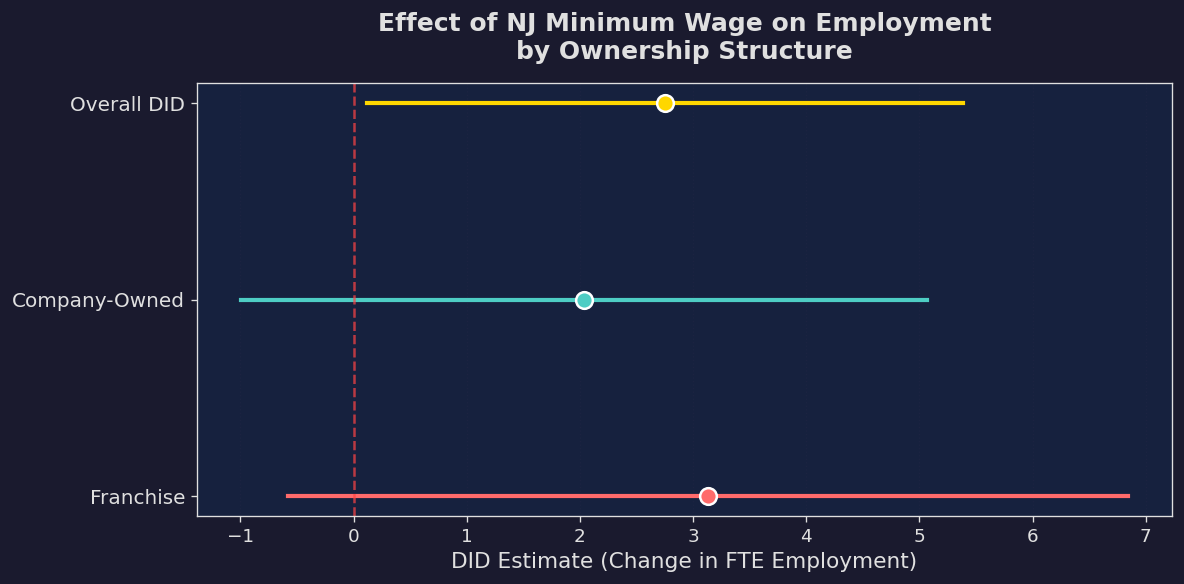

In [86]:
# ============================================================
# Forest Plot: DID Estimates by Subgroup
# ============================================================

# Compute overall DID
nj_d = df_raw.loc[df_raw["STATE"]==1, "dFTE"].dropna()
pa_d = df_raw.loc[df_raw["STATE"]==0, "dFTE"].dropna()
overall_est = nj_d.mean() - pa_d.mean()
overall_se = np.sqrt(nj_d.std()**2/len(nj_d) + pa_d.std()**2/len(pa_d))

plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor': '#16213e',
    'axes.edgecolor': '#e0e0e0',
    'axes.labelcolor': '#e0e0e0',
    'text.color': '#e0e0e0',
    'xtick.color': '#e0e0e0',
    'ytick.color': '#e0e0e0',
    'grid.color': '#2a2a4a',
    'font.size': 11,
    'figure.dpi': 120
})

fig, ax = plt.subplots(figsize=(10, 5))

labels = ["Overall DID", "Company-Owned", "Franchise"]
ests = [overall_est, did_results["Company-Owned"]["est"], did_results["Franchise"]["est"]]
ses = [overall_se, did_results["Company-Owned"]["se"], did_results["Franchise"]["se"]]
colors = ["#FFD700", "#4ECDC4", "#FF6B6B"]

y_pos = np.arange(len(labels))[::-1]

for i in range(len(labels)):
    lo = ests[i] - 1.96 * ses[i]
    hi = ests[i] + 1.96 * ses[i]
    ax.plot([lo, hi], [y_pos[i], y_pos[i]], color=colors[i], linewidth=2.5)
    ax.plot(ests[i], y_pos[i], 'o', color=colors[i], markersize=10,
            markeredgecolor='white', markeredgewidth=1.5, zorder=5)

ax.axvline(x=0, color='#FF4444', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=12)
ax.set_xlabel('DID Estimate (Change in FTE Employment)', fontsize=13)
ax.set_title('Effect of NJ Minimum Wage on Employment\nby Ownership Structure',
             fontsize=15, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3, linestyle=':')

plt.tight_layout()
plt.savefig('forest_plot_hte.png', dpi=200, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

Code Explanation: Forest plot visualizing DID point estimates and 95% confidence intervals for overall, company-owned, and franchise subgroups.

### Additional HTE: Small vs. Large Restaurants

Following instructor guidance, we define firm size using pre-treatment (Wave 1) FTE employment to avoid endogeneity. Stores are classified as "Small" or "Large" based on the median FTE in Wave 1.

In [87]:
# ============================================================
# HTE by Pre-Treatment Firm Size (Small vs Large)
# ============================================================

# Define size using Wave 1 FTE (pre-treatment) to avoid endogeneity
median_fte = df_raw["Full_Time_Equivalent1"].median()
df_raw["large"] = (df_raw["Full_Time_Equivalent1"] >= median_fte).astype(int)
df_raw["NJ_x_large"] = df_raw["NJ"] * df_raw["large"]

print(f"Median pre-treatment FTE: {median_fte}")
print(f"Small stores (below median): {(df_raw['large']==0).sum()}")
print(f"Large stores (at or above median): {(df_raw['large']==1).sum()}")

# DID by firm size
size_did = {}
for label, val in [("Small", 0), ("Large", 1)]:
    sub = df_raw[df_raw["large"] == val]
    nj = sub[sub["STATE"]==1]["dFTE"].dropna()
    pa = sub[sub["STATE"]==0]["dFTE"].dropna()
    d = nj.mean() - pa.mean()
    se = np.sqrt(nj.std()**2/len(nj) + pa.std()**2/len(pa))
    size_did[label] = {"est": d, "se": se}
    print(f"\n{label} restaurants:")
    print(f"  NJ change: {nj.mean():+.2f} (N={len(nj)})")
    print(f"  PA change: {pa.mean():+.2f} (N={len(pa)})")
    print(f"  DID: {d:+.2f} (SE={se:.2f}, t={d/se:.2f})")

# Interaction regression
reg_df["large"] = (reg_df["Full_Time_Equivalent1"] >= median_fte).astype(int)
reg_df["NJ_x_large"] = reg_df["NJ"] * reg_df["large"]

model_size = smf.ols("dFTE ~ NJ + large + NJ_x_large + KFC + ROYS + WEND + CO_OWNED", data=reg_df).fit(cov_type="HC1")
print("\n" + "=" * 65)
print("Regression: NJ x Firm Size Interaction")
print("=" * 65)
print(model_size.summary().tables[1])
print(f"\nEffect on Small stores:         {model_size.params['NJ']:+.2f} (p={model_size.pvalues['NJ']:.4f})")
print(f"Additional effect for Large:     {model_size.params['NJ_x_large']:+.2f} (p={model_size.pvalues['NJ_x_large']:.4f})")

Median pre-treatment FTE: 19.5
Small stores (below median): 207
Large stores (at or above median): 203

Small restaurants:
  NJ change: +2.11 (N=156)
  PA change: +2.57 (N=34)
  DID: -0.45 (SE=1.33, t=-0.34)

Large restaurants:
  NJ change: -1.21 (N=153)
  PA change: -6.30 (N=41)
  DID: +5.09 (SE=2.01, t=2.54)

Regression: NJ x Firm Size Interaction
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.7022      1.462      3.901      0.000       2.837       8.567
NJ            -1.4944      1.203     -1.243      0.214      -3.852       0.863
large        -11.3145      2.333     -4.850      0.000     -15.887      -6.742
NJ_x_large     6.7690      2.464      2.747      0.006       1.939      11.599
KFC           -3.2083      1.012     -3.171      0.002      -5.191      -1.225
ROYS          -2.7267      1.057     -2.579      0.010      -4.799      -0.654
WEND          -0

Code Explanation: Following instructor guidance, define firm size using pre-treatment (Wave 1) FTE employment to avoid endogeneity. Stores are split at the median into "Small" and "Large." Compute separate DID estimates and estimate an interaction regression (NJ × Large) with HC1 robust standard errors.

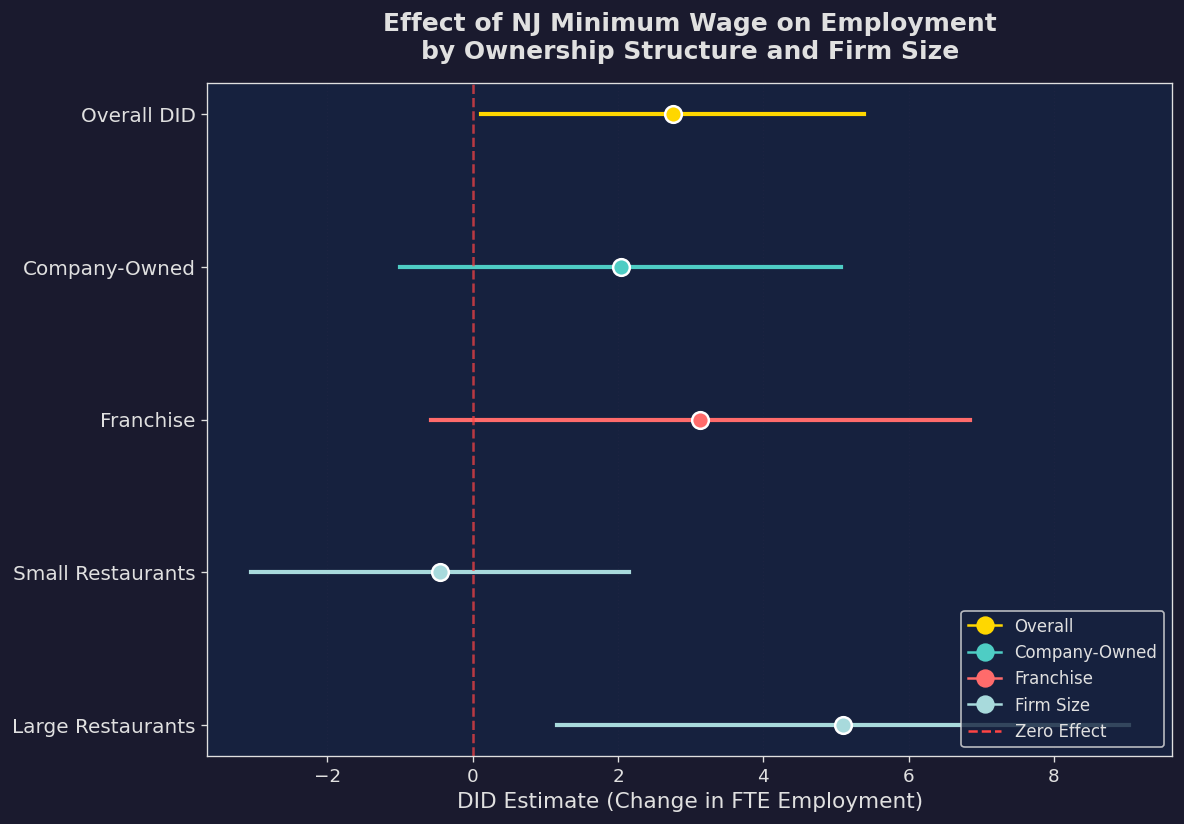

In [88]:
# ============================================================
# Updated Forest Plot: Ownership + Firm Size
# ============================================================
fig, ax = plt.subplots(figsize=(10, 7))

labels = ["Overall DID", "Company-Owned", "Franchise", "Small Restaurants", "Large Restaurants"]
ests = [
    overall_est,
    did_results["Company-Owned"]["est"],
    did_results["Franchise"]["est"],
    size_did["Small"]["est"],
    size_did["Large"]["est"]
]
ses_list = [
    overall_se,
    did_results["Company-Owned"]["se"],
    did_results["Franchise"]["se"],
    size_did["Small"]["se"],
    size_did["Large"]["se"]
]
colors = ["#FFD700", "#4ECDC4", "#FF6B6B", "#A8DADC", "#A8DADC"]

y_pos = np.arange(len(labels))[::-1]

for i in range(len(labels)):
    lo = ests[i] - 1.96 * ses_list[i]
    hi = ests[i] + 1.96 * ses_list[i]
    ax.plot([lo, hi], [y_pos[i], y_pos[i]], color=colors[i], linewidth=2.5)
    ax.plot(ests[i], y_pos[i], 'o', color=colors[i], markersize=10,
            markeredgecolor='white', markeredgewidth=1.5, zorder=5)

ax.axvline(x=0, color='#FF4444', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=12)
ax.set_xlabel('DID Estimate (Change in FTE Employment)', fontsize=13)
ax.set_title('Effect of NJ Minimum Wage on Employment\nby Ownership Structure and Firm Size',
             fontsize=15, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3, linestyle=':')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='#FFD700', label='Overall', markersize=10, linestyle='-'),
    Line2D([0], [0], marker='o', color='#4ECDC4', label='Company-Owned', markersize=10, linestyle='-'),
    Line2D([0], [0], marker='o', color='#FF6B6B', label='Franchise', markersize=10, linestyle='-'),
    Line2D([0], [0], marker='o', color='#A8DADC', label='Firm Size', markersize=10, linestyle='-'),
    Line2D([0], [0], color='#FF4444', linestyle='--', label='Zero Effect'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
          facecolor='#16213e', edgecolor='#e0e0e0')

plt.tight_layout()
plt.savefig('forest_plot_final.png', dpi=200, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

Code Explanation: Updated forest plot combining all five subgroup DID estimates (Overall, Company-Owned, Franchise, Small, Large) with 95% confidence intervals.

## Executive Summary

This extension analyzes whether there would be HTE on two dimensions due to the increase in the minimum wage and employment rate within New Jersey in 1992. To be specific, the ownership structure of the restaurant and the scales of the restaurant. For the purpose of dealing with the endogenous problem when using the processed index,  I used the quantity of employment before the processing of Wave 1 FTE to determine the scale of the restaurant. The ownership analysis showed the direction of heterogeneity, which the DID estimated value for the franchised restaurant was greater than the value of the company-operated chain restaurants. To be specific, a positive 3.13 FTE from the franchise restaurant of DiD estimated value and a positive 2.04 FTE for the company-operated chain restaurants. The interaction terms are not statistically significant, with p=0.85. Therefore, we could not reject the null hypothesis for the two groups have the same reactions. I also run a placebo test within the state of Pennsylvania. The value of p=0.87 shows that the difference in ownership structure is not the confounding factor. However, there is a significant statistical difference in the scale of the restaurants. To be specific, the DiD for the restaurants with larger scale ( With FTE that are higher than the median before processing) is positive 5.09, with t=2.54. While the effect of smaller restaurants is closer to 0, which is a value of -0.45. Furthermore, the NJ*Large interaction term is significant at p=0.006 level, which shows that the positive employment effect related to the minimum wage is mainly centralized in the restaurants with larger scales.


In short, all of the findings above improve the variety of the background for Card and Krueger (1994). The overall DiD of +2.76 FTE is a weighted average in reality, it covers the meaningful HTE from the scale size of restaurants. To be specific, the positive employment effect is driven mainly by the restaurants with a larger scale, while smaller restaurants are basically not affected. This situation aligns with the logic that larger firms have the capability to respond to the increase in minimum wage by price transmission and operational adjustments. At the same time, the two ownership types are both non-negative effects, which further support the core ideology of the original analysis. In other words, the minimum wage did not result in a decrease in employment. Therefore, it further improved my understanding, which the recognition of firm scale instead of structure could be one of the critical marginal dimensions during the encounter with changes in the effect process.

### GenAI Tools & Prompts Used

| Tool | Purpose |
|------|---------|
| Claude (Anthropic) | Pair-programmer for extension design, regression code, visualization, and placebo test framework |

**Prompts used in this extension:**

1. "I am replicating Card & Krueger (1994). The original paper controls for company-ownership but never tests whether company-owned and franchise stores respond differently to the minimum wage. Help me design a heterogeneous treatment effects analysis using interaction terms (NJ x CO_OWNED and GAP x CO_OWNED) in a first-difference regression framework."

2. "Design a placebo test: within Pennsylvania only, test whether company-owned and franchise stores have different employment trends. Use a Welch t-test to rule out confounding."

3. "I need to split stores into small vs large using pre-treatment (Wave 1) FTE to avoid endogeneity. Write a regression with NJ x large interaction and chain/ownership controls using statsmodels."

4. "I have DID estimates for Overall, Company-Owned, Franchise, Small, and Large subgroups. Write a Python matplotlib script using a dark theme to create a horizontal coefficient plot (forest plot) with 95% confidence intervals and a red dashed vertical line at x=0."


In [89]:
df_raw.to_csv("card_krueger_clean.csv", index=False)

Code Explanation: Data Export